In [16]:
import pandas as pd

df = pd.read_csv("loan_data_new.csv")

print(df)

       Age  Gender    Education  Person Income  Employee Experience  \
0       22  female       Master          71948                    0   
1       21  female  High School          12282                    0   
2       25  female  High School          12438                    3   
3       23  female     Bachelor          79753                    0   
4       24    male       Master          66135                    1   
...    ...     ...          ...            ...                  ...   
44995   27    male    Associate          47971                    6   
44996   37  female    Associate          65800                   17   
44997   33    male    Associate          56942                    7   
44998   29    male     Bachelor          33164                    4   
44999   24    male  High School          51609                    1   

      Home Onwership  Loan Amount        Loan Intent  Loan interest Rate  \
0               RENT        35000           PERSONAL               16.0

In [17]:
print(df.shape)
print(df.columns)

(45000, 14)
Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status'],
      dtype='str')


In [18]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  str    
 2   Education            45000 non-null  str    
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  str    
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  str    
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  str    
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 4.8 MB
None


In [19]:
df.isna().sum()

Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64

In [25]:
X = df[[
    "Person Income",
    "Employee Experience",
    "Loan interest Rate",
    "Loan percentage",
    "Credit History",
    "Credit Score"
]]

y = df["Loan Amount"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [28]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.02,-44.04,312.1 , 1.11, 79.15, 0.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Person Income','Employee Experience','Loan interest Rate', 'Loan percentage','Credit History','Credit Score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4348
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [29]:
y_pred = model.predict(X_test)

print(y_pred)

[ 8425.37618686  9158.49467002 10166.97776201 ...  9716.78899961
  9038.52890925  8861.50965645]


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print( r2)

0.09611148299990135


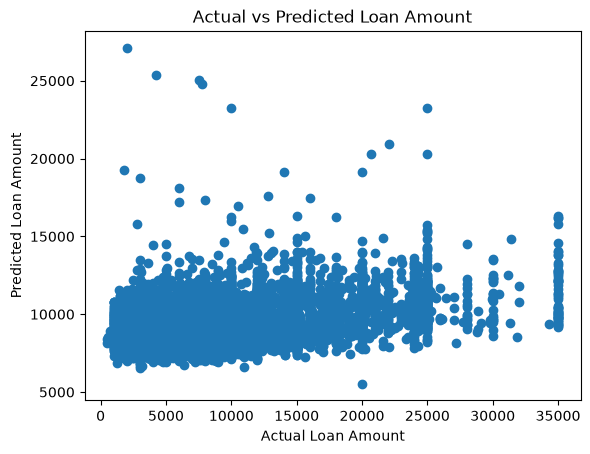

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Amount")

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

Mean Absolute Error: 4682.998409900312


In [33]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print( rmse)

6031.786896722146
